# New-Gen Cross-Family Fusion Analysis

Consensus notebook that compares layer scores from multiple blind families and builds a simple fusion score.

In [ ]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams.update({'figure.figsize': (16, 5), 'axes.grid': True, 'grid.alpha': 0.3})

ROOT = Path.cwd().resolve()
for p in [ROOT, *ROOT.parents]:
    if (p / 'notebooks' / 'new-gen' / '_newgen_utils.py').exists():
        ROOT = p
        break

sys.path.insert(0, str(ROOT / 'notebooks' / 'new-gen'))
from _newgen_utils import latest_structural_runs, select_run_files, load_json, get_model_name, iter_valid_tests, safe_layer_map, sorted_layers_from_map, get_target_layer

In [ ]:
model_filter = ['gpt2-large', 'gpt2-xl', 'qwen3-4b']
use_sweep_aware = True

selection = 'latest_model_sweep' if use_sweep_aware else 'latest_model'
all_run_files = latest_structural_runs(
    ROOT,
    max_files=500,
    model_substrings=model_filter,
    include_outputs=True,
    recursive=True,
)
run_files = select_run_files(all_run_files, selection=selection)
payloads = [load_json(p) for p in run_files]
print(f'Loaded {len(payloads)} run files (selection={selection})')
for p in run_files:
    print(' -', p.name)

Loaded 9 run files
 - rome_structural_qwen3-4b_tk64_tf3_tl3_nl2_rw9_lw5-9-13_s02_r01_2026-03-24_14-23-43.json
 - rome_structural_qwen3-4b_tk50_tf2_tl2_nl1_rw5_lw3-5-7_s01_r01_2026-03-24_14-07-42.json
 - rome_structural_gpt2-xl_tk64_tf3_tl3_nl2_rw9_lw5-9-13_s02_r01_2026-03-24_13-57-39.json
 - rome_structural_gpt2-xl_tk50_tf2_tl2_nl1_rw5_lw3-5-7_s01_r01_2026-03-24_13-47-38.json
 - rome_structural_gpt2-large_tk64_tf3_tl3_nl2_rw9_lw5-9-13_s02_r01_2026-03-24_13-42-54.json
 - rome_structural_gpt2-large_tk50_tf2_tl2_nl1_rw5_lw3-5-7_s01_r01_2026-03-24_13-38-10.json
 - rome_structural_gpt2-xl_2026-03-24_02-47-55.json
 - rome_structural_gpt2-large_2026-03-24_01-20-36.json
 - rome_structural_qwen3-4b_2026-03-23_18-09-51.json


In [3]:
def get_family_map(case, family):
    if family == 'spectral':
        return case.get('spectral_detection', {}).get('rome_hybrid_scores', {})
    if family == 'attention':
        return case.get('attention_detection', {}).get('combined_score', {})
    if family == 'rank1_blind':
        return case.get('rank1_blind_detection', {}).get('combined_score', {})
    if family == 'symmetry':
        return case.get('symmetry_detection', {}).get('combined_score', {})
    return {}

def rank_normalize_map(layer_map):
    layers = sorted_layers_from_map(layer_map)
    if not layers:
        return {}
    vals = np.array([safe_layer_map(layer_map, l, np.nan) for l in layers], dtype=float)
    vals = np.nan_to_num(vals, nan=-np.inf, posinf=-np.inf, neginf=-np.inf)
    order = np.argsort(vals)
    ranks = np.empty_like(vals, dtype=float)
    ranks[order] = np.arange(len(vals), dtype=float)
    ranks = ranks / max(1, len(vals) - 1)
    return {int(l): float(ranks[i]) for i, l in enumerate(layers)}

families = ['spectral', 'attention', 'rank1_blind', 'symmetry']
rows = []
pred_rows = []

for payload in payloads:
    model = get_model_name(payload)
    for case in iter_valid_tests(payload):
        case_id = case.get('case_id', -1)
        target = get_target_layer(payload, case)

        fam_maps = {}
        layer_union = set()
        for fam in families:
            m = rank_normalize_map(get_family_map(case, fam))
            if not m:
                continue
            fam_maps[fam] = m
            layer_union.update(m.keys())

        if not fam_maps or not layer_union:
            continue

        layers = sorted(layer_union)
        fusion_vals = []
        for layer in layers:
            vals = []
            for fam in families:
                if fam in fam_maps:
                    vals.append(fam_maps[fam].get(layer, np.nan))
                    rows.append({
                        'model': model,
                        'case_id': case_id,
                        'family': fam,
                        'layer': layer,
                        'score_rank01': fam_maps[fam].get(layer, np.nan),
                        'target_layer': target if target is not None else np.nan,
                    })
            fusion = float(np.nanmean(vals)) if len(vals) else np.nan
            fusion_vals.append((layer, fusion))

        if fusion_vals:
            pred_layer = max(fusion_vals, key=lambda x: x[1])[0]
            pred_rows.append({
                'model': model,
                'case_id': case_id,
                'target_layer': target,
                'pred_layer_fusion': pred_layer,
                'fusion_correct': bool(pred_layer == target) if target is not None else False,
            })

fusion_df = pd.DataFrame(rows)
pred_df = pd.DataFrame(pred_rows)
fusion_df.head(), pred_df.head()

(           model  case_id       family  layer  score_rank01  target_layer
 0  Qwen/Qwen3-4B        0     spectral      0      0.000000            12
 1  Qwen/Qwen3-4B        0    attention      0      1.000000            12
 2  Qwen/Qwen3-4B        0  rank1_blind      0      0.771429            12
 3  Qwen/Qwen3-4B        0     symmetry      0      0.800000            12
 4  Qwen/Qwen3-4B        0     spectral      1      0.028571            12,
            model  case_id  target_layer  pred_layer_fusion  fusion_correct
 0  Qwen/Qwen3-4B        0            12                  5           False
 1  Qwen/Qwen3-4B        1            12                  5           False
 2  Qwen/Qwen3-4B        2            12                  5           False
 3  Qwen/Qwen3-4B        0            12                 16           False
 4  Qwen/Qwen3-4B        1            12                 16           False)

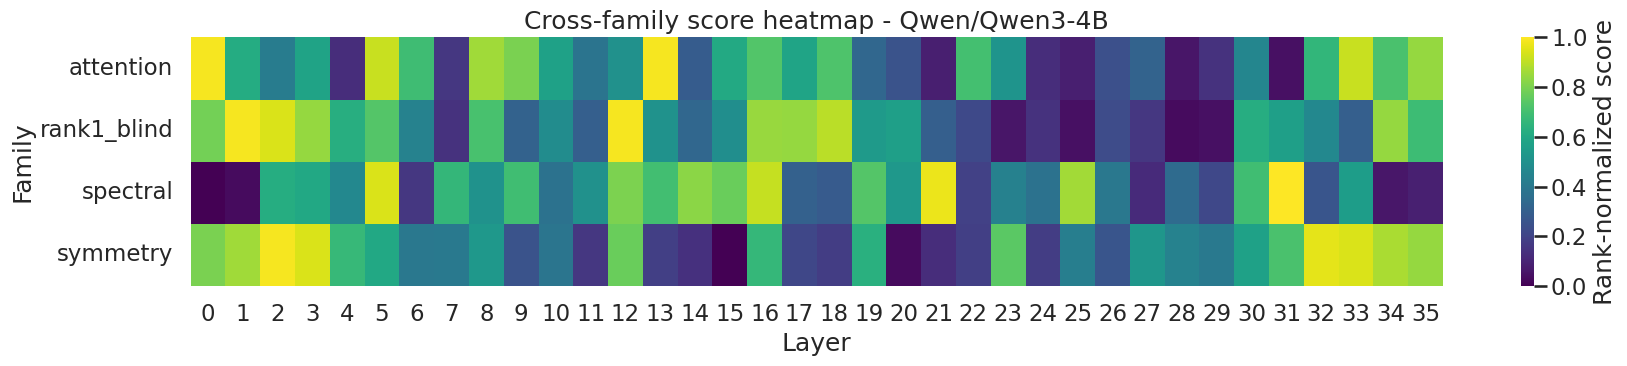

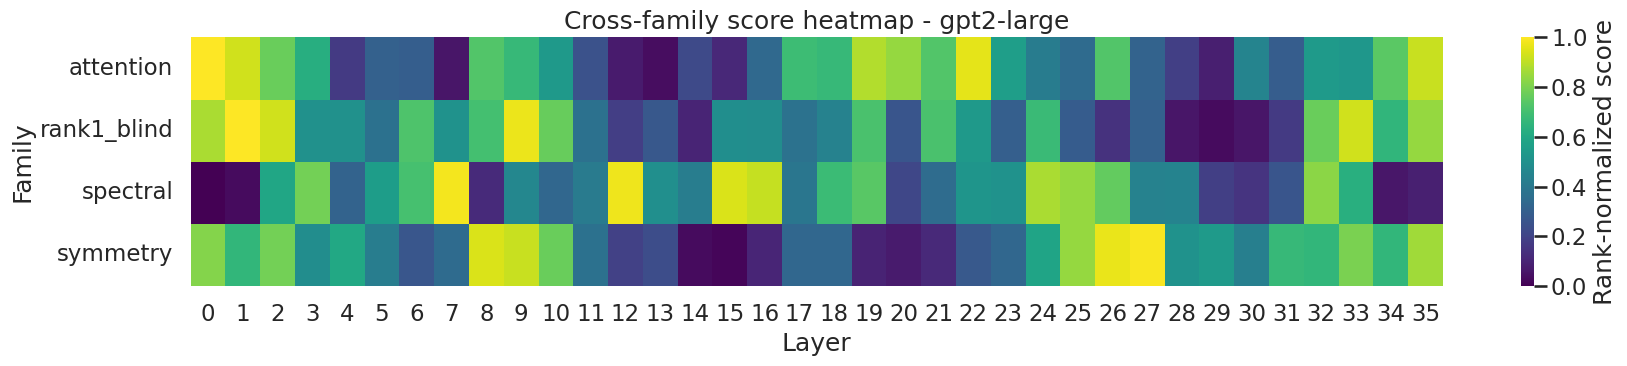

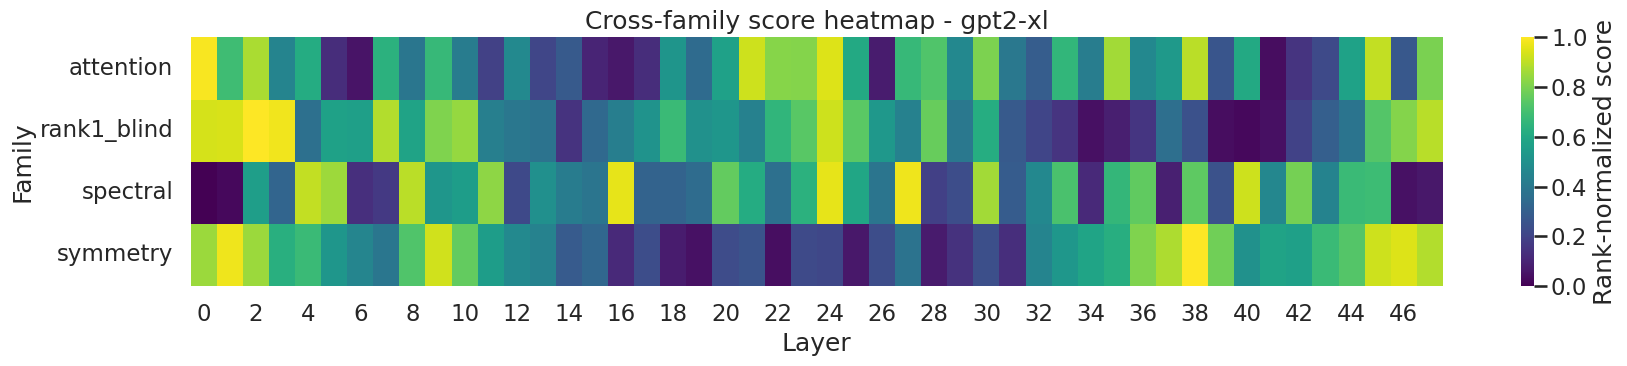

In [4]:
if fusion_df.empty:
    print('No fusion-ready rows found in selected runs.')
else:
    for model in sorted(fusion_df['model'].unique()):
        model_df = fusion_df[fusion_df['model'] == model]
        pivot = (model_df.groupby(['family', 'layer'])['score_rank01']
                 .mean()
                 .unstack(fill_value=np.nan))
        plt.figure(figsize=(18, 4))
        sns.heatmap(pivot, cmap='viridis', vmin=0.0, vmax=1.0, cbar_kws={'label': 'Rank-normalized score'})
        plt.title(f'Cross-family score heatmap - {model}')
        plt.xlabel('Layer')
        plt.ylabel('Family')
        plt.tight_layout()
        plt.show()

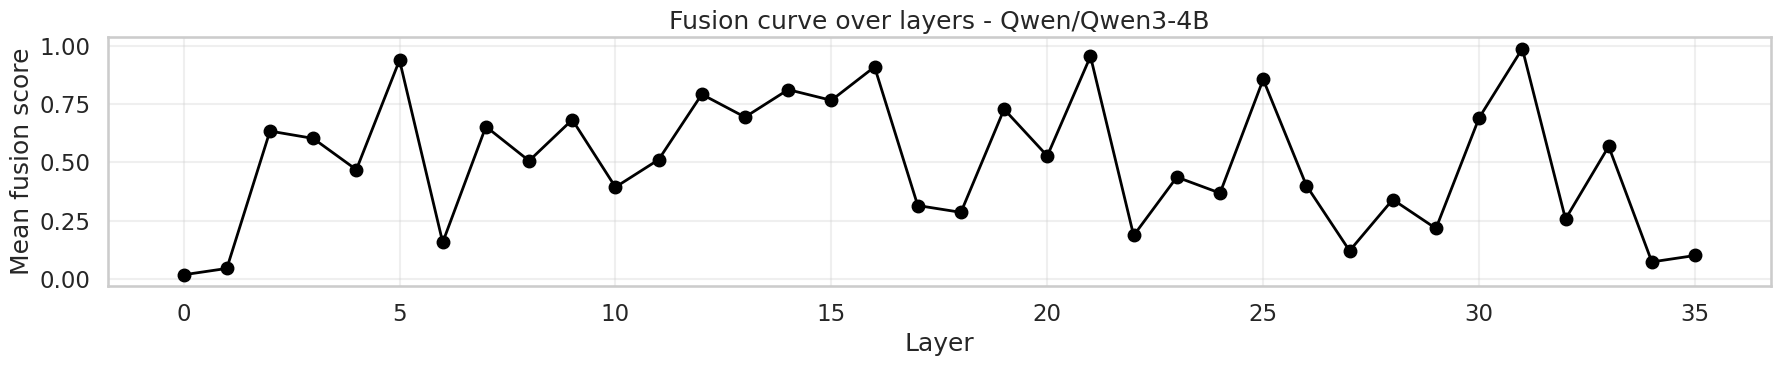

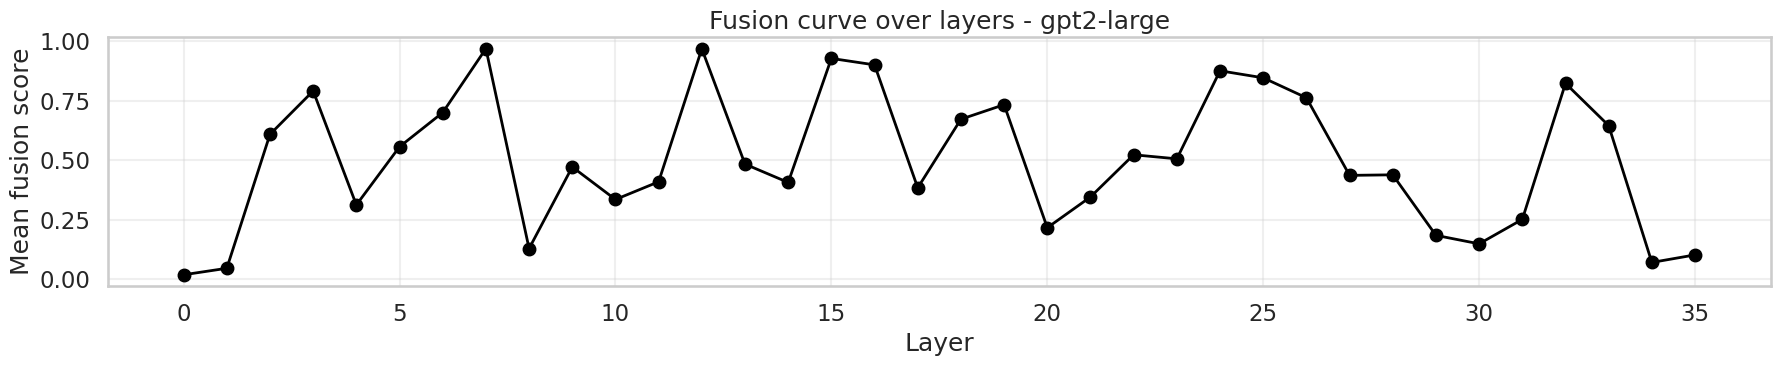

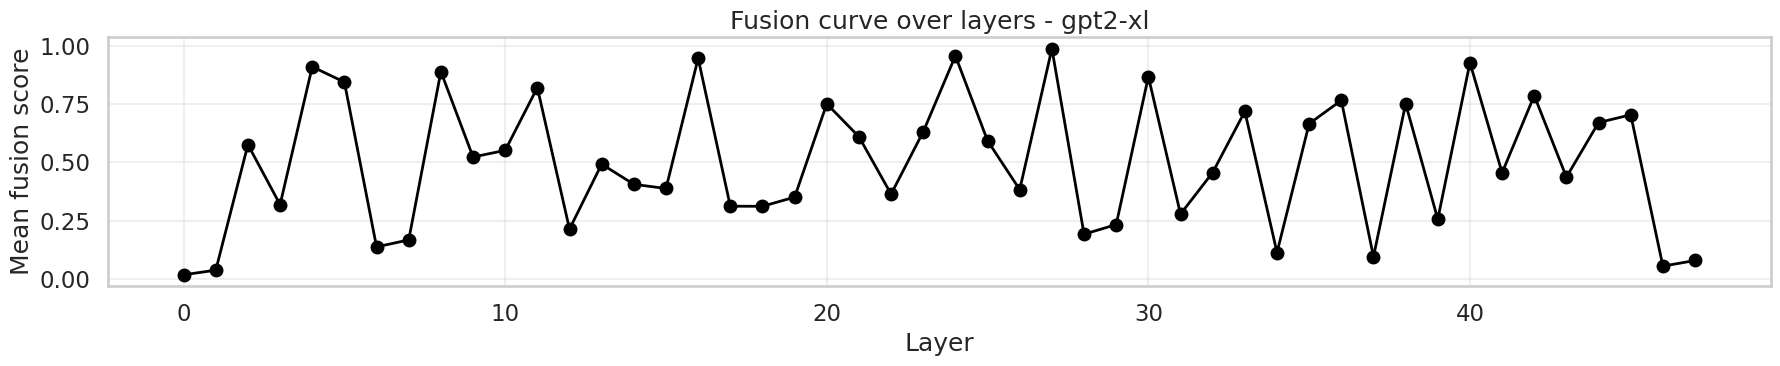

In [5]:
if not fusion_df.empty:
    fusion_line = (fusion_df
                   .groupby(['model', 'case_id', 'layer'])['score_rank01']
                   .mean()
                   .reset_index(name='fusion_score'))

    agg = fusion_line.groupby(['model', 'layer'])['fusion_score'].mean().reset_index()
    for model in sorted(agg['model'].unique()):
        sub = agg[agg['model'] == model]
        plt.figure(figsize=(18, 4))
        plt.plot(sub['layer'], sub['fusion_score'], marker='o', linewidth=2, color='black')
        plt.title(f'Fusion curve over layers - {model}')
        plt.xlabel('Layer')
        plt.ylabel('Mean fusion score')
        plt.tight_layout()
        plt.show()

In [6]:
if pred_df.empty:
    print('No fusion predictions found.')
else:
    fusion_summary = pred_df.groupby('model').agg(
        n=('fusion_correct', 'size'),
        fusion_accuracy=('fusion_correct', 'mean'),
    ).reset_index()
    display(fusion_summary)
    display(pred_df.head(20))

,model,n,fusion_accuracy
0,Qwen/Qwen3-4B,106,0.000000
1,gpt2-large,106,0.566038
2,gpt2-xl,106,0.000000


,model,case_id,target_layer,pred_layer_fusion,fusion_correct
0,Qwen/Qwen3-4B,0,12,5,False
1,Qwen/Qwen3-4B,1,12,5,False
2,Qwen/Qwen3-4B,2,12,5,False
3,Qwen/Qwen3-4B,0,12,16,False
4,Qwen/Qwen3-4B,1,12,16,False
5,Qwen/Qwen3-4B,2,12,16,False
6,gpt2-xl,0,18,9,False
7,gpt2-xl,1,18,9,False
8,gpt2-xl,2,18,9,False
9,gpt2-xl,0,18,45,False
